In [2]:
import os
import zipfile
import pyarrow.parquet as pq
import pandas as pd

folder = r"F:\sanazi\python\data science\code\tamrin\proje\Tennis Schema\Tennis Schema\tennis_data"

data = {}

for file in os.listdir(folder): 
    if file.endswith(".zip"): 

        zip_path = os.path.join(folder, file) 

        with zipfile.ZipFile(zip_path) as z: 
            for parquet_file in z.namelist():

                if parquet_file.endswith(".parquet"): 

                    with z.open(parquet_file) as f:
                        df = pq.read_table(f).to_pandas()
                    table_name =os.path.basename(os.path.dirname(parquet_file))[4:-8] + os.path.basename(parquet_file)[:-17] 

                    if table_name not in data:
                        data[table_name] = [] 
                    data[table_name].append(df) 


for table_name in data:
    data[table_name] = pd.concat(data[table_name], ignore_index=True)

print(data.keys())

C:\Users\sepehr\AppData\Local\Temp\ipykernel_8856\1606281692.py:30: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data[table_name] = pd.concat(data[table_name], ignore_index=True)


dict_keys(['matchaway_team', 'matchaway_team_score', 'matchevent', 'matchhome_team', 'matchhome_team_score', 'matchround', 'matchseason', 'matchtime', 'matchtournament', 'matchvenue', 'oddsodds', 'point_by_pointpbp', 'statisticsstatistics', 'tennis_powerpower', 'votesvotes'])


In [3]:
statistics = data["statisticsstatistics"]

print(statistics.columns)
print(statistics["statistic_name"].unique())

Index(['match_id', 'period', 'statistic_category_name', 'statistic_name',
       'home_stat', 'away_stat', 'compare_code', 'statistic_type',
       'value_type', 'home_value', 'away_value', 'home_total', 'away_total'],
      dtype='object')
['aces' 'double_faults' 'first_serve' 'second_serve' 'first_serve_points'
 'second_serve_points' 'service_games_played' 'break_points_saved' 'total'
 'service_points_won' 'receiver_points_won' 'max_points_in_a_row'
 'total_won' 'service_games_won' 'max_games_in_a_row'
 'first_serve_return_points' 'second_serve_return_points'
 'return_games_played' 'break_points_converted' 'tiebreaks']


In [4]:
import pandas as pd


statistics = data["statisticsstatistics"]


double_fault = statistics[
    statistics["statistic_name"] == "double_faults"
]


home = data["matchhome_team"][["match_id", "gender"]]
away = data["matchaway_team"][["match_id", "gender"]]


home_df = double_fault.merge(home, on="match_id")
home_df["double_faults"] = home_df["home_value"]
home_df["gender"] = home_df["gender"]


away_df = double_fault.merge(away, on="match_id")
away_df["double_faults"] = away_df["away_value"]
away_df["gender"] = away_df["gender"]


result = pd.concat([
    home_df[["gender", "double_faults"]],
    away_df[["gender", "double_faults"]]
], ignore_index=True)


print(result.groupby("gender")["double_faults"].mean())
print(result.groupby("gender")["double_faults"].agg(["count", "mean", "std"]))

gender
F    2.070056
M    1.578071
Name: double_faults, dtype: float64
         count      mean       std
gender                            
F       122545  2.070056  2.207455
M       161935  1.578071  1.773147


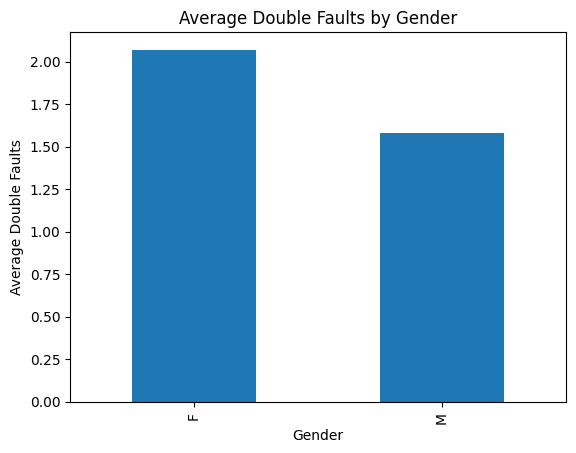

In [5]:
import matplotlib.pyplot as plt

mean_df = result.groupby("gender")["double_faults"].mean()

mean_df.plot(kind="bar")

plt.title("Average Double Faults by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Double Faults")

plt.show()